# 🧠 Notebook 02 — NLP Sentiment Analysis Pipeline
### Senti-Recommend: Hybrid AI Tool Discovery Engine
**PGD Data Science with AI — Final Project**

---

## What This Notebook Does

This notebook is the **NLP engine** of the project. It trains a machine learning model to classify user reviews as **Positive, Neutral, or Negative**, generates a compound sentiment score for each review, and performs **Aspect-Based Sentiment Analysis (ABSA)** — detecting how users feel about specific dimensions like ease of use, pricing, and support.

### Pipeline Overview
```
Raw Reviews → Text Cleaning → Sentiment Labels (from stars) → TF-IDF Features
    → Logistic Regression Model → Sentiment Scores → ABSA → App-Level Aggregation
    → sentiment_scores.csv (input for Recommender Engine)
```

> **Why Logistic Regression + TF-IDF instead of VADER?**  
> VADER uses a generic dictionary. Our model is *trained on actual AI tool reviews*, making it domain-specific and more academically defensible as a custom NLP contribution.


## 📦 Step 1: Import Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, json, warnings
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score, f1_score,
                              precision_recall_fscore_support)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
print(f"   sklearn : {__import__('sklearn').__version__}")


✅ All libraries imported successfully!
   pandas  : 2.3.3
   numpy   : 2.3.5
   sklearn : 1.7.2


## 📂 Step 2: Load the Data

We load two datasets:
- **cleaned_reviews.csv** — 69,726 user reviews (our main NLP input)
- **cleaned_metadata.csv** — 482 AI apps with ratings, categories, pricing


In [32]:
reviews  = pd.read_csv('cleaned_reviews.csv')
metadata = pd.read_csv('cleaned_metadata.csv')

print(f"📊 Reviews dataset  : {reviews.shape[0]:,} rows × {reviews.shape[1]} columns")
print(f"📊 Metadata dataset : {metadata.shape[0]:,} rows × {metadata.shape[1]} columns")
print()
print("── Reviews sample columns ──")
print(reviews.dtypes)


📊 Reviews dataset  : 69,726 rows × 13 columns
📊 Metadata dataset : 482 rows × 26 columns

── Reviews sample columns ──
app_id             object
review_id          object
user_name          object
review_text        object
star_rating         int64
thumbs_up_count     int64
review_date        object
reply_text         object
reply_date         object
scraped_at         object
review_length       int64
is_short_review      bool
has_reply            bool
dtype: object


In [3]:
reviews.head(3)


,app_id,review_id,user_name,review_text,star_rating,thumbs_up_count,review_date,reply_text,reply_date,scraped_at,review_length,is_short_review,has_reply
0,ai.chat.gpt.bot,67119987-51f4-44b1-bc96-65d9ac7b74f9,Leafand Lotus,"Weak. Can't upload images for reference, the a...",1,5,2026-02-03 20:36:24,Hello! Thank you for your feedback. We'd appre...,2026-02-09 16:42:08,2026-02-21 09:50:35.531042,373,False,True
1,ai.chat.gpt.bot,39f0ae17-5bb6-462c-976c-497a468e6d71,Hayden Winn,It has lower models and only allows 5 free pro...,1,7,2026-01-08 03:40:33,NaN,NaN,2026-02-21 09:50:35.531081,490,False,False
2,ai.chat.gpt.bot,28426411-3f9f-4d26-b4eb-14fb027297e9,Jenn,it's a little tricky sometimes to get the righ...,5,922,2024-09-09 23:16:54,NaN,NaN,2026-02-21 09:50:35.531093,494,False,False


In [4]:
print("⭐ Star Rating Distribution:")
print(reviews['star_rating'].value_counts().sort_index())
print(f"\n📝 Avg review length : {reviews['review_length'].mean():.0f} chars")
print(f"📝 Null review texts  : {reviews['review_text'].isna().sum()}")


⭐ Star Rating Distribution:
star_rating
1    18057
2     4567
3     4927
4     7363
5    34812
Name: count, dtype: int64

📝 Avg review length : 162 chars
📝 Null review texts  : 0


## 📊 Step 3: Exploratory Data Analysis (EDA)

Before training any model, we visualise the data to understand distributions and imbalances.


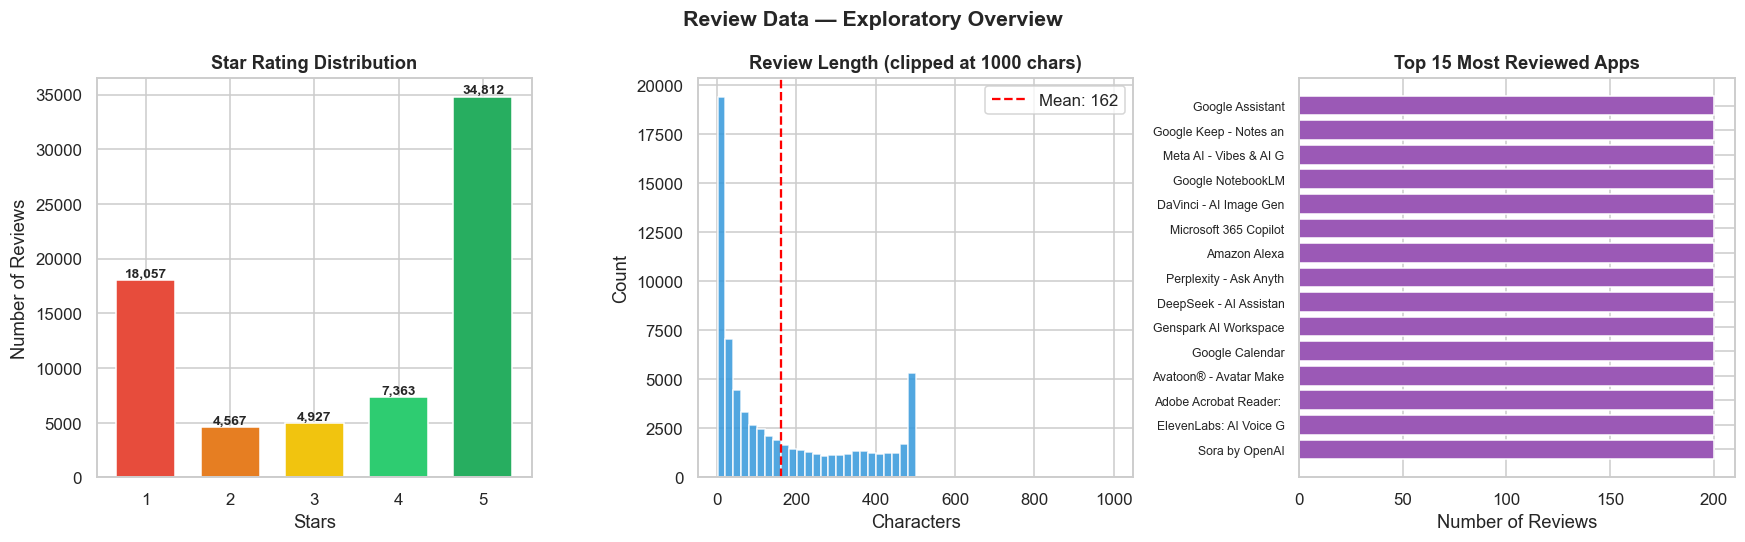

✅ Chart saved: eda_overview.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Review Data — Exploratory Overview", fontsize=14, fontweight='bold')

# Plot 1: Star Rating Distribution
star_counts = reviews['star_rating'].value_counts().sort_index()
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
axes[0].bar(star_counts.index, star_counts.values, color=colors, edgecolor='white', width=0.7)
axes[0].set_title("Star Rating Distribution", fontweight='bold')
axes[0].set_xlabel("Stars"); axes[0].set_ylabel("Number of Reviews")
for x, y in zip(star_counts.index, star_counts.values):
    axes[0].text(x, y + 300, f"{y:,}", ha='center', fontsize=9, fontweight='bold')

# Plot 2: Review Length Distribution
axes[1].hist(reviews['review_length'].clip(upper=1000), bins=50,
             color='#3498db', edgecolor='white', alpha=0.85)
axes[1].set_title("Review Length (clipped at 1000 chars)", fontweight='bold')
axes[1].set_xlabel("Characters"); axes[1].set_ylabel("Count")
axes[1].axvline(reviews['review_length'].mean(), color='red', linestyle='--',
                label=f"Mean: {reviews['review_length'].mean():.0f}")
axes[1].legend()

# Plot 3: Top 15 Most Reviewed Apps
app_name_map = metadata.set_index('app_id')['app_name'].to_dict()
top_apps = reviews['app_id'].value_counts().head(15)
top_labels = [app_name_map.get(aid, aid)[:22] for aid in top_apps.index]
axes[2].barh(range(15), top_apps.values[::-1], color='#9b59b6', edgecolor='white')
axes[2].set_yticks(range(15))
axes[2].set_yticklabels(top_labels[::-1], fontsize=8)
axes[2].set_title("Top 15 Most Reviewed Apps", fontweight='bold')
axes[2].set_xlabel("Number of Reviews")

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Chart saved: eda_overview.png")


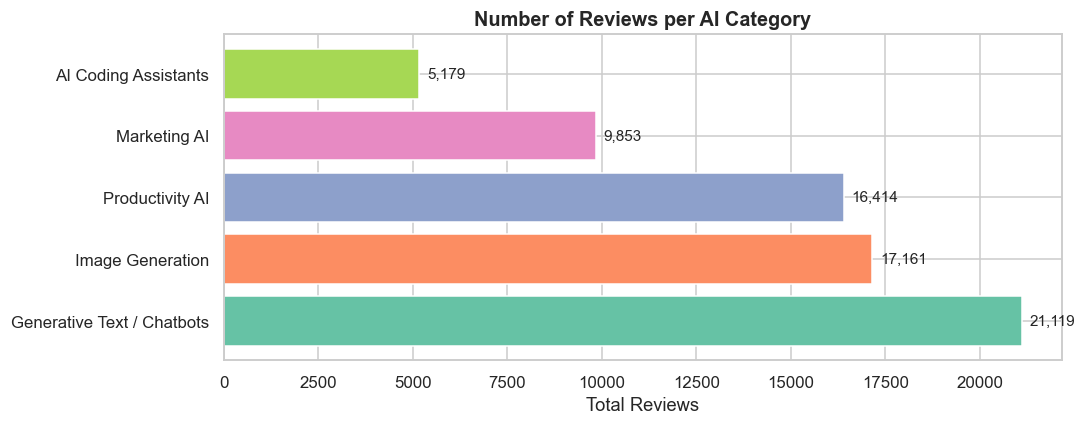

In [6]:
# Reviews per project category
reviews_with_cat = reviews.merge(metadata[['app_id','project_category']], on='app_id', how='left')
cat_order = reviews_with_cat['project_category'].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
palette = sns.color_palette("Set2", len(cat_order))
bars = ax.barh(cat_order.index, cat_order.values, color=palette, edgecolor='white')
ax.set_title("Number of Reviews per AI Category", fontweight='bold', fontsize=13)
ax.set_xlabel("Total Reviews")
for bar, val in zip(bars, cat_order.values):
    ax.text(val + 200, bar.get_y() + bar.get_height()/2, f"{val:,}", va='center', fontsize=10)
plt.tight_layout()
plt.savefig('reviews_by_category.png', bbox_inches='tight', dpi=130)
plt.show()


## 🔧 Step 4: Text Preprocessing

Raw review text contains noise — URLs, numbers, special characters. We clean it so the model focuses on meaningful words.

**Steps:**
1. Lowercase everything
2. Remove URLs and email addresses  
3. Remove special characters (keep apostrophes for contractions like "don't")
4. Normalise whitespace

> We keep negation words (not, never, no) because "not good" ≠ "good". TF-IDF bigrams handle this.


In [7]:
def clean_text(text):
    """Cleans a single review string for NLP processing."""
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+|\S+@\S+', ' ', text)   # remove URLs/emails
    text = re.sub(r"[^a-z\'\s]", ' ', text)                    # keep letters/apostrophes
    text = re.sub(r'\s+', ' ', text).strip()                     # normalise spaces
    return text

print("🔄 Cleaning 69,726 reviews...")
reviews['clean_text'] = reviews['review_text'].apply(clean_text)

# Remove near-empty reviews
before = len(reviews)
reviews = reviews[reviews['clean_text'].str.len() > 5].reset_index(drop=True)
print(f"✅ Cleaning complete! Removed {before - len(reviews)} empty reviews.")
print(f"   Dataset size: {len(reviews):,} reviews remain")
print()
print("Before:", reviews['review_text'].iloc[0][:120])
print("After :", reviews['clean_text'].iloc[0][:120])


🔄 Cleaning 69,726 reviews...
✅ Cleaning complete! Removed 7102 empty reviews.
   Dataset size: 62,624 reviews remain

Before: Weak. Can't upload images for reference, the app can't view them. I bought the app for image assistance and it can't eve
After : weak can't upload images for reference the app can't view them i bought the app for image assistance and it can't even d


## 🏷️ Step 5: Create Sentiment Labels

We use **Distant Supervision** — a well-established NLP technique that uses existing metadata (star ratings) as proxy labels for sentiment.

| Stars | Label | Code |
|-------|-------|------|
| 1–2 ⭐ | Negative | 0 |
| 3 ⭐ | Neutral | 1 |
| 4–5 ⭐ | Positive | 2 |


In [8]:
def star_to_sentiment(star):
    if star <= 2: return 0
    elif star == 3: return 1
    else: return 2

reviews['sentiment_label'] = reviews['star_rating'].apply(star_to_sentiment)
label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
reviews['sentiment_name'] = reviews['sentiment_label'].map(label_map)

print("📊 Sentiment Label Distribution:")
dist = reviews['sentiment_name'].value_counts()
for sentiment, count in dist.items():
    pct = count / len(reviews) * 100
    bar = '█' * int(pct / 2)
    print(f"  {sentiment:10s}: {count:6,} ({pct:5.1f}%)  {bar}")
print()
print("⚠️  Class imbalance noted — handled with class_weight='balanced' in the model.")


📊 Sentiment Label Distribution:
  Positive  : 36,216 ( 57.8%)  ████████████████████████████
  Negative  : 21,859 ( 34.9%)  █████████████████
  Neutral   :  4,549 (  7.3%)  ███

⚠️  Class imbalance noted — handled with class_weight='balanced' in the model.


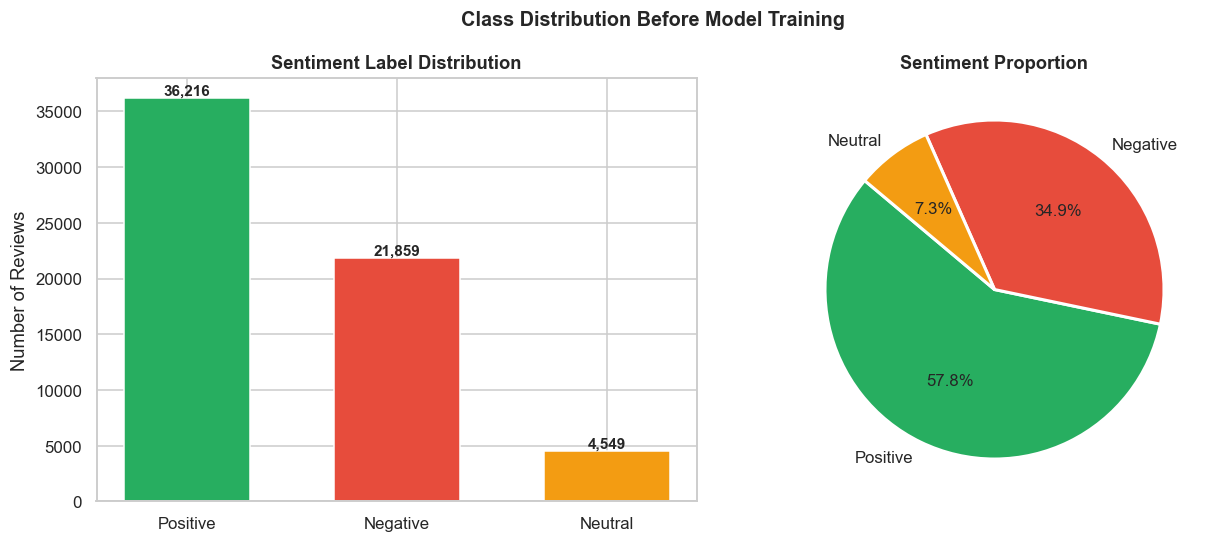

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
colors = {'Negative': '#e74c3c', 'Neutral': '#f39c12', 'Positive': '#27ae60'}
counts = reviews['sentiment_name'].value_counts()

bars = ax1.bar(counts.index, counts.values,
               color=[colors[c] for c in counts.index], edgecolor='white', width=0.6)
ax1.set_title("Sentiment Label Distribution", fontweight='bold')
ax1.set_ylabel("Number of Reviews")
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f"{val:,}", ha='center', fontsize=10, fontweight='bold')

ax2.pie(counts.values, labels=counts.index,
        colors=[colors[c] for c in counts.index],
        autopct='%1.1f%%', startangle=140,
        wedgeprops={'edgecolor':'white', 'linewidth': 2})
ax2.set_title("Sentiment Proportion", fontweight='bold')

plt.suptitle("Class Distribution Before Model Training", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_label_dist.png', bbox_inches='tight', dpi=130)
plt.show()


## 🔢 Step 6: TF-IDF Feature Extraction

Machine learning models require numbers, not text. **TF-IDF** converts each review into a numeric vector:
- **TF** (Term Frequency): How often a word appears in *this* review
- **IDF** (Inverse Document Frequency): How rare the word is across *all* reviews  
- Common words like "the" get low scores; distinctive words like "crashes" get high scores

**Why bigrams (`ngram_range=(1,2)`)?**  
So "not good" is one feature, not two separate words. This preserves negation meaning.


In [10]:
tfidf = TfidfVectorizer(
    max_features=15000,     # Top 15,000 most informative features
    ngram_range=(1, 2),     # Unigrams + bigrams (handles negation)
    min_df=3,               # Ignore words in fewer than 3 reviews
    max_df=0.90,            # Ignore words in >90% of reviews (too common)
    sublinear_tf=True,      # Log-scale term frequency
    strip_accents='unicode'
)

print("🔄 Fitting TF-IDF on all review texts...")
X = tfidf.fit_transform(reviews['clean_text'])
y = reviews['sentiment_label'].values

print(f"✅ TF-IDF matrix shape: {X.shape[0]:,} reviews × {X.shape[1]:,} features")
print(f"   Matrix sparsity: {(1 - X.nnz / (X.shape[0]*X.shape[1]))*100:.1f}% sparse")
print()

feature_names = tfidf.get_feature_names_out()
bigrams = [f for f in feature_names if ' ' in f][:15]
print(f"Sample unigrams : {list(feature_names[:10])}")
print(f"Sample bigrams  : {bigrams}")


🔄 Fitting TF-IDF on all review texts...
✅ TF-IDF matrix shape: 62,624 reviews × 15,000 features
   Matrix sparsity: 99.7% sparse

Sample unigrams : ['aap', 'abilities', 'ability', 'ability to', 'able', 'able to', 'about', 'about ai', 'about and', 'about anything']
Sample bigrams  : ['ability to', 'able to', 'about ai', 'about and', 'about anything', 'about every', 'about how', 'about it', 'about minutes', 'about my', 'about of', 'about that', 'about the', 'about their', 'about this']


## ✂️ Step 7: Train / Test Split

- **Training set (80%)** — the model learns from this
- **Test set (20%)** — we evaluate on data the model has *never seen*

`stratify=y` ensures all three sentiment classes appear proportionally in both splits.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("✅ Train/Test Split Complete:")
print(f"   Training : {X_train.shape[0]:,} samples ({X_train.shape[0]/len(y)*100:.1f}%)")
print(f"   Testing  : {X_test.shape[0]:,} samples ({X_test.shape[0]/len(y)*100:.1f}%)")
print()

train_dist = Counter(y_train)
for k in sorted(train_dist):
    print(f"   {label_map[k]:10s} in train: {train_dist[k]:,} ({train_dist[k]/len(y_train)*100:.1f}%)")


✅ Train/Test Split Complete:
   Training : 50,099 samples (80.0%)
   Testing  : 12,525 samples (20.0%)

   Negative   in train: 17,487 (34.9%)
   Neutral    in train: 3,639 (7.3%)
   Positive   in train: 28,973 (57.8%)


## 🤖 Step 8: Train the Sentiment Classifier

**Why Logistic Regression?**
- Fast to train on 55,000+ samples
- Produces probability scores (needed for compound sentiment scoring)
- Interpretable — we can inspect which words drive each sentiment
- Well-established baseline in NLP classification literature

`class_weight='balanced'` compensates for the class imbalance automatically.


In [12]:
print("🔄 Training Logistic Regression classifier...")
print("   (may take 15–30 seconds)")

model = LogisticRegression(
    class_weight='balanced',    # Compensate for class imbalance
    C=1.0,                      # Regularisation strength
    max_iter=1000,
    solver='lbfgs',
    multi_class='multinomial',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("✅ Training complete!")
print()
print(f"   Train Accuracy : {model.score(X_train, y_train)*100:.2f}%")
print(f"   Test Accuracy  : {model.score(X_test,  y_test)*100:.2f}%")


🔄 Training Logistic Regression classifier...
   (may take 15–30 seconds)
✅ Training complete!

   Train Accuracy : 86.40%
   Test Accuracy  : 80.03%


## 📈 Step 9: Evaluate Model Performance

| Metric | What it tells us |
|--------|-----------------|
| **Accuracy** | % of reviews correctly classified overall |
| **Precision** | Of predicted-Positive reviews, how many truly were? |
| **Recall** | Of all truly-Positive reviews, how many did we find? |
| **F1-Score** | Harmonic mean of Precision & Recall (best single metric) |


In [13]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

print("=" * 60)
print("  SENTIMENT MODEL — CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred,
                             target_names=['Negative','Neutral','Positive']))
print(f"Overall Accuracy  : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Weighted F1-Score : {f1_score(y_test, y_pred, average='weighted')*100:.2f}%")


  SENTIMENT MODEL — CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.85      0.80      0.82      4372
     Neutral       0.24      0.48      0.32       910
    Positive       0.92      0.84      0.88      7243

    accuracy                           0.80     12525
   macro avg       0.67      0.71      0.68     12525
weighted avg       0.85      0.80      0.82     12525

Overall Accuracy  : 80.03%
Weighted F1-Score : 81.95%


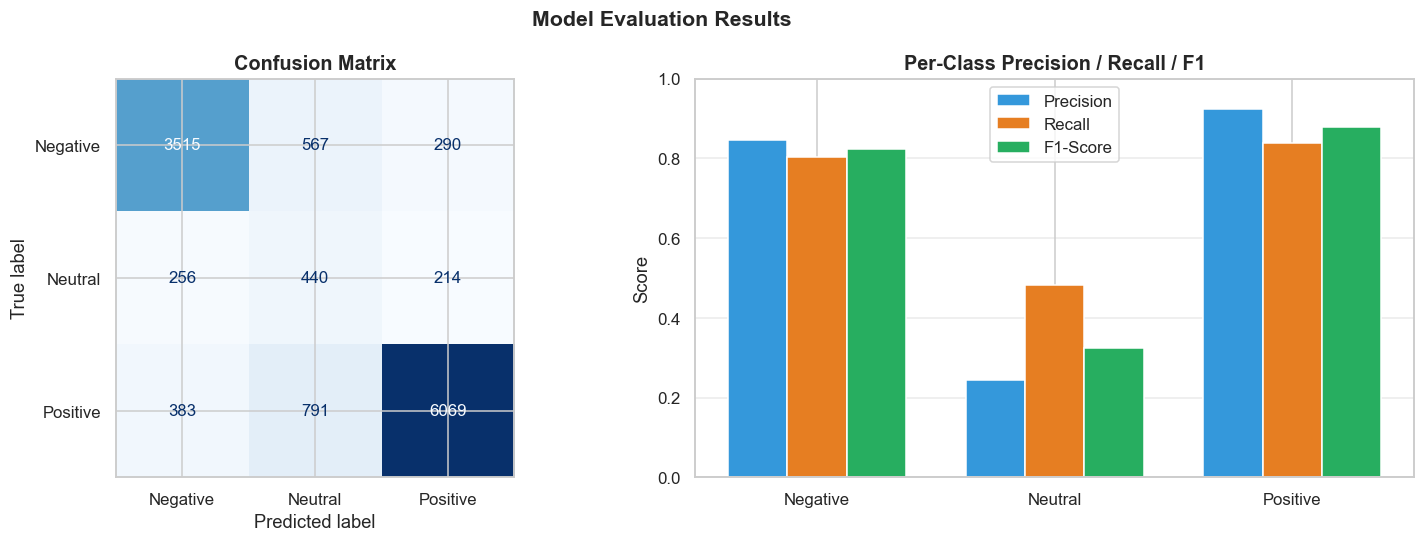

✅ Chart saved: model_evaluation.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Negative','Neutral','Positive'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Confusion Matrix", fontweight='bold', fontsize=13)

# Per-Class Metrics Bar Chart
precision, recall, f1_scores, _ = precision_recall_fscore_support(y_test, y_pred, labels=[0,1,2])
x = np.arange(3)
w = 0.25
class_names = ['Negative', 'Neutral', 'Positive']
axes[1].bar(x - w, precision, w, label='Precision', color='#3498db', edgecolor='white')
axes[1].bar(x,     recall,    w, label='Recall',    color='#e67e22', edgecolor='white')
axes[1].bar(x + w, f1_scores, w, label='F1-Score',  color='#27ae60', edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(class_names)
axes[1].set_ylim(0, 1.0); axes[1].set_ylabel("Score")
axes[1].set_title("Per-Class Precision / Recall / F1", fontweight='bold', fontsize=13)
axes[1].legend(); axes[1].grid(axis='y', alpha=0.4)

plt.suptitle("Model Evaluation Results", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_evaluation.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Chart saved: model_evaluation.png")


In [15]:
# 5-Fold Cross-Validation on 20,000-sample subset (for speed)
print("🔄 Running 5-Fold Cross-Validation on 20,000-sample subset...")
sample_idx = np.random.RandomState(42).choice(len(y), size=20000, replace=False)
cv_scores = cross_val_score(model, X[sample_idx], y[sample_idx],
                            cv=5, scoring='f1_weighted', n_jobs=-1)
print(f"\nCV F1 Scores : {[f'{s:.3f}' for s in cv_scores]}")
print(f"Mean F1      : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
print("\n✅ Low standard deviation = stable, reliable model")


🔄 Running 5-Fold Cross-Validation on 20,000-sample subset...

CV F1 Scores : ['0.816', '0.811', '0.811', '0.801', '0.807']
Mean F1      : 80.92% ± 0.51%

✅ Low standard deviation = stable, reliable model


## 🔍 Step 10: Inspect Model — Most Influential Words

Logistic Regression is interpretable — we can see exactly which words push predictions towards each class. This is crucial for **academic credibility**: you can explain *why* the model classifies a review as negative or positive.


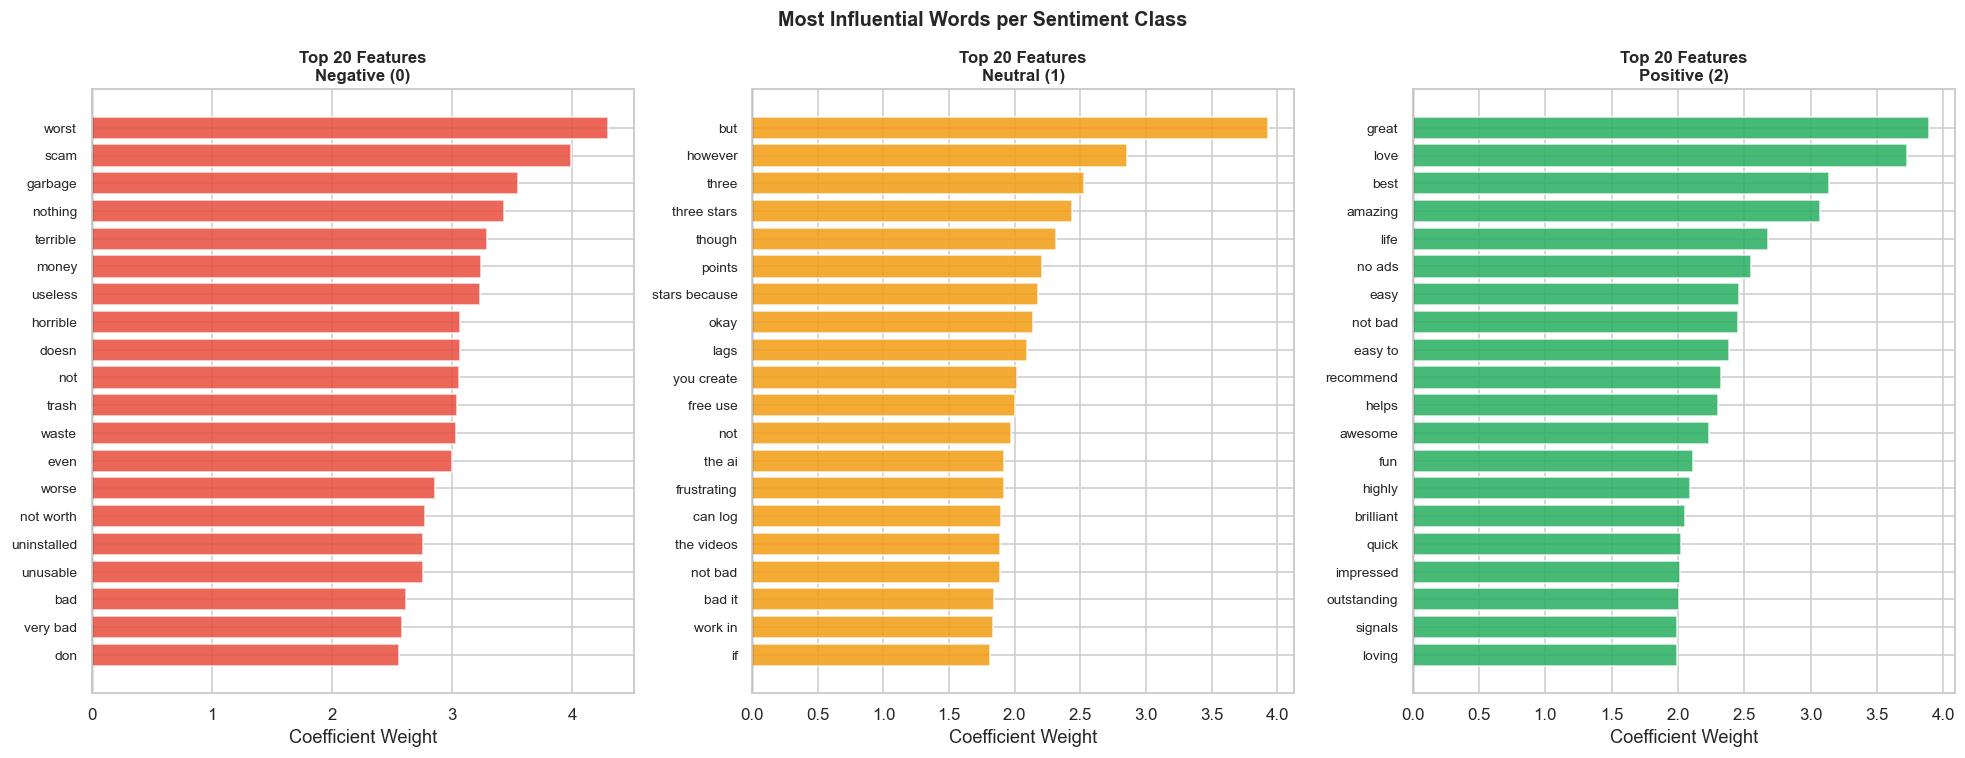

✅ Chart saved: feature_importance.png


In [16]:
feature_names = tfidf.get_feature_names_out()
coef = model.coef_   # Shape: (3 classes, num_features)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
class_names = ['Negative (0)', 'Neutral (1)', 'Positive (2)']
bar_colors  = ['#e74c3c', '#f39c12', '#27ae60']

for i, (ax, cls_name, color) in enumerate(zip(axes, class_names, bar_colors)):
    top_n = 20
    top_idx    = np.argsort(coef[i])[-top_n:][::-1]
    top_words  = [feature_names[j] for j in top_idx]
    top_vals   = [coef[i][j]       for j in top_idx]
    
    ax.barh(range(top_n), top_vals[::-1], color=color, alpha=0.85, edgecolor='white')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_words[::-1], fontsize=9)
    ax.set_title(f"Top 20 Features\n{cls_name}", fontweight='bold', fontsize=11)
    ax.set_xlabel("Coefficient Weight")
    ax.axvline(0, color='black', linewidth=0.8)

plt.suptitle("Most Influential Words per Sentiment Class", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Chart saved: feature_importance.png")


## 💯 Step 11: Generate Sentiment Scores for All Reviews

We apply the trained model to every review to generate:
- `pred_label` / `pred_name` — Predicted sentiment class
- `prob_negative`, `prob_neutral`, `prob_positive` — Class probabilities
- `sentiment_score` — Compound score from **−1.0 to +1.0**
  - Formula: `P(Positive) − P(Negative)`
  - +1.0 = Extremely positive | −1.0 = Extremely negative | ~0 = Neutral

This `sentiment_score` is the **core NLP signal** that feeds into the hybrid recommender.


In [17]:
print("🔄 Scoring all reviews (may take 20–30 seconds)...")

all_probs = model.predict_proba(X)
all_preds = model.predict(X)

reviews['prob_negative'] = all_probs[:, 0]
reviews['prob_neutral']  = all_probs[:, 1]
reviews['prob_positive'] = all_probs[:, 2]
reviews['pred_label']    = all_preds
reviews['pred_name']     = pd.Series(all_preds).map(label_map).values
reviews['sentiment_score'] = reviews['prob_positive'] - reviews['prob_negative']

print("✅ Scoring complete!")
print()
print(reviews[['review_text','star_rating','pred_name','sentiment_score']].head(6).to_string(max_colwidth=55))


🔄 Scoring all reviews (may take 20–30 seconds)...
✅ Scoring complete!

                                              review_text  star_rating pred_name  sentiment_score
0  Weak. Can't upload images for reference, the app ca...            1  Negative        -0.734975
1  It has lower models and only allows 5 free prompts ...            1  Negative        -0.382711
2  it's a little tricky sometimes to get the right wor...            5  Positive         0.533939
3  No experience, every single ai chat app is the exac...            1  Negative        -0.769016
4  Another cash grab. Can't see the features or use th...            1  Negative        -0.708255
5  Really puts my words into how I see the situation o...            5   Neutral         0.116072


📊 Validation: Mean Sentiment Score by Star Rating
   (Expected: score should increase monotonically from 1⭐ to 5⭐)

             Mean Score   Std Dev  Count
star_rating                             
1             -0.658800  0.335067  17460
2             -0.403503  0.378717   4399
3             -0.001215  0.306495   4549
4              0.395459  0.401134   6628
5              0.656323  0.321368  29588


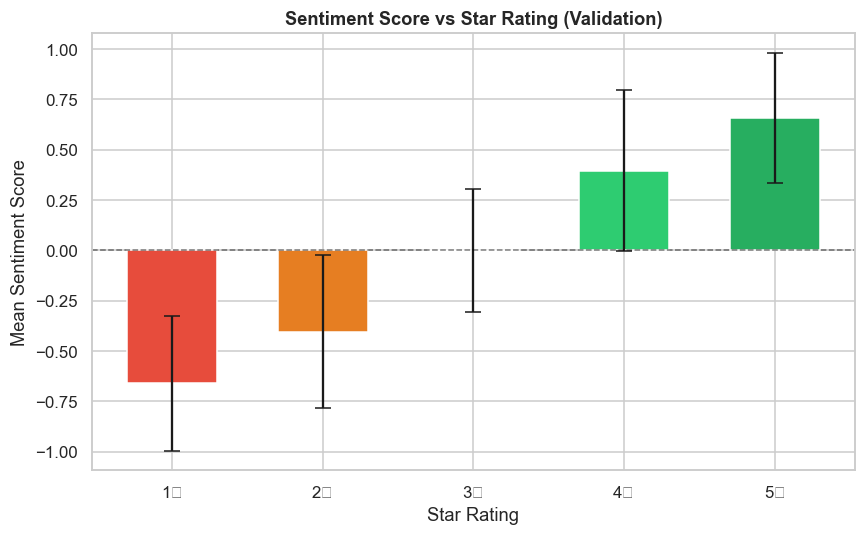

In [18]:
# Validation: sentiment score should increase with star rating
print("📊 Validation: Mean Sentiment Score by Star Rating")
print("   (Expected: score should increase monotonically from 1⭐ to 5⭐)")
print()
validation = reviews.groupby('star_rating')['sentiment_score'].agg(['mean','std','count'])
validation.columns = ['Mean Score', 'Std Dev', 'Count']
print(validation)

fig, ax = plt.subplots(figsize=(8, 5))
stars = validation.index
means = validation['Mean Score']
stds  = validation['Std Dev']
colors_v = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
ax.bar(stars, means, yerr=stds, capsize=5, color=colors_v, edgecolor='white', width=0.6)
ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel("Star Rating"); ax.set_ylabel("Mean Sentiment Score")
ax.set_title("Sentiment Score vs Star Rating (Validation)", fontweight='bold')
ax.set_xticks(stars); ax.set_xticklabels([f"{s}⭐" for s in stars])
plt.tight_layout()
plt.savefig('validation_score_vs_stars.png', bbox_inches='tight', dpi=130)
plt.show()


## 🎯 Step 12: Aspect-Based Sentiment Analysis (ABSA)

Overall sentiment gives one number per review. But users feel differently about *different aspects*:

> *"The features are amazing but customer support is terrible and way too expensive"*

ABSA detects this nuance by scanning each sentence for aspect keywords, then measuring sentiment in that sentence.

**5 Aspects Analysed:**
| Aspect | Example Keywords |
|--------|----------------|
| 🟢 Ease of Use | easy, intuitive, simple, learning curve |
| 💰 Pricing | price, expensive, affordable, subscription |
| 🛠️ Customer Support | support, response, customer service |
| ⚡ Performance | fast, slow, crash, lag, reliable |
| 🔧 Features | features, functionality, integration, options |


In [19]:
# ── Aspect and Sentiment Lexicons ─────────────────────────────────────────────

ASPECT_KEYWORDS = {
    'ease_of_use': [
        'easy', 'simple', 'intuitive', 'user friendly', 'user-friendly',
        'straightforward', 'beginner', 'accessible', 'learning curve',
        'difficult', 'complicated', 'confusing', 'hard to use', 'complex',
        'clunky', 'smooth', 'seamless', 'convenient', 'overwhelming'
    ],
    'pricing': [
        'price', 'pricing', 'expensive', 'cheap', 'affordable', 'cost',
        'subscription', 'paid', 'free', 'premium', 'value for money',
        'worth', 'overpriced', 'budget', 'plan', 'tier', 'billing',
        'trial', 'money', 'fee', 'charge', 'refund'
    ],
    'customer_support': [
        'support', 'customer service', 'help desk', 'response', 'team',
        'staff', 'agent', 'contact', 'ticket', 'reply', 'chat support',
        'helpful', 'unhelpful', 'ignored', 'resolved', 'quick response',
        'responsive', 'unresponsive'
    ],
    'performance': [
        'fast', 'slow', 'speed', 'quick', 'lag', 'crash', 'bug', 'glitch',
        'freeze', 'reliable', 'unreliable', 'stable', 'performance',
        'loading', 'responsive', 'snappy', 'delay', 'timeout', 'error',
        'accurate', 'accuracy'
    ],
    'features': [
        'feature', 'features', 'functionality', 'function', 'tool', 'tools',
        'option', 'options', 'capability', 'integration', 'plugin', 'api',
        'update', 'missing', 'lacks', 'limited', 'powerful', 'robust',
        'versatile', 'customise', 'customize'
    ]
}

POSITIVE_WORDS = {
    'great', 'excellent', 'amazing', 'fantastic', 'wonderful', 'love', 'loved',
    'best', 'perfect', 'awesome', 'brilliant', 'incredible', 'outstanding',
    'superb', 'terrific', 'easy', 'simple', 'fast', 'helpful', 'useful',
    'good', 'nice', 'smooth', 'clean', 'efficient', 'reliable', 'impressed',
    'happy', 'satisfied', 'worth', 'recommend', 'powerful', 'intuitive',
    'accurate', 'quick', 'responsive', 'stable', 'seamless', 'convenient'
}

NEGATIVE_WORDS = {
    'bad', 'terrible', 'awful', 'horrible', 'worst', 'hate', 'hated',
    'useless', 'broken', 'fail', 'failed', 'disappointing', 'disappointed',
    'slow', 'crash', 'bug', 'glitch', 'error', 'problem', 'issue',
    'expensive', 'overpriced', 'waste', 'cancel', 'refund', 'scam',
    'difficult', 'confusing', 'limited', 'missing', 'lacks', 'poor',
    'frustrating', 'annoying', 'mediocre', 'unreliable', 'ignored',
    'unresponsive', 'freeze', 'lag', 'delay', 'inaccurate', 'complicated'
}

NEGATION_WORDS = {
    'not', 'no', 'never', 'cannot', "can't", "won't", "doesn't",
    "isn't", "wasn't", "weren't", "don't", "didn't", 'hardly', 'barely'
}

print("✅ Lexicons defined!")
print(f"   Aspects        : {list(ASPECT_KEYWORDS.keys())}")
print(f"   Positive words : {len(POSITIVE_WORDS)}")
print(f"   Negative words : {len(NEGATIVE_WORDS)}")


✅ Lexicons defined!
   Aspects        : ['ease_of_use', 'pricing', 'customer_support', 'performance', 'features']
   Positive words : 39
   Negative words : 43


In [20]:
def analyse_aspects(text):
    """
    Aspect-Based Sentiment Analysis for a single review.
    
    Algorithm:
    1. Split text into sentences
    2. For each sentence, check if aspect keywords are present
    3. Count positive/negative words in same sentence (with negation flipping)
    4. Return mean score per aspect: +1=positive, -1=negative, None=not mentioned
    """
    if pd.isna(text) or len(str(text)) < 5:
        return {aspect: None for aspect in ASPECT_KEYWORDS}
    
    text_lower = str(text).lower()
    sentences  = re.split(r'[.!?;\n]', text_lower)
    aspect_scores = {aspect: [] for aspect in ASPECT_KEYWORDS}
    
    for sentence in sentences:
        if len(sentence.strip()) < 3:
            continue
        words = sentence.split()
        
        for aspect, keywords in ASPECT_KEYWORDS.items():
            if not any(kw in sentence for kw in keywords):
                continue
            
            pos_count = 0
            neg_count = 0
            for j, word in enumerate(words):
                clean_word = re.sub(r"[^a-z']", '', word)
                is_negated = any(
                    words[k].rstrip("',") in NEGATION_WORDS
                    for k in range(max(0, j-3), j)
                )
                if clean_word in POSITIVE_WORDS:
                    neg_count += 1 if is_negated else 0
                    pos_count += 0 if is_negated else 1
                elif clean_word in NEGATIVE_WORDS:
                    pos_count += 1 if is_negated else 0
                    neg_count += 0 if is_negated else 1
            
            if pos_count + neg_count > 0:
                aspect_scores[aspect].append(
                    (pos_count - neg_count) / (pos_count + neg_count)
                )
    
    return {
        aspect: round(float(np.mean(scores)), 4) if scores else None
        for aspect, scores in aspect_scores.items()
    }

# ── Test on examples ──────────────────────────────────────────────────────────
tests = [
    "The app is very easy to use and intuitive, but pricing is way too expensive.",
    "Customer support is amazing and responded quickly. Features are limited.",
    "Terrible customer service. The tool crashes constantly and is overpriced."
]
print("🧪 ABSA Test:")
for rev in tests:
    print(f"\n📝 '{rev[:80]}'")
    scores = analyse_aspects(rev)
    for aspect, score in scores.items():
        if score is not None:
            emoji = "🟢" if score > 0.2 else ("🔴" if score < -0.2 else "🟡")
            print(f"   {emoji} {aspect:22s}: {score:+.2f}")


🧪 ABSA Test:

📝 'The app is very easy to use and intuitive, but pricing is way too expensive.'
   🟢 ease_of_use           : +0.33
   🟢 pricing               : +0.33

📝 'Customer support is amazing and responded quickly. Features are limited.'
   🟢 customer_support      : +1.00
   🟢 performance           : +1.00
   🔴 features              : -1.00

📝 'Terrible customer service. The tool crashes constantly and is overpriced.'
   🔴 pricing               : -1.00
   🔴 customer_support      : -1.00
   🔴 performance           : -1.00
   🔴 features              : -1.00


In [21]:
print("🔄 Running ABSA on all reviews (estimated 2–4 minutes)...")
print("   Each review is analysed for 5 sentiment aspects...")

absa_results = reviews['review_text'].apply(analyse_aspects)
absa_df = pd.DataFrame(absa_results.tolist())
absa_df.columns = [f'absa_{col}' for col in absa_df.columns]
reviews = pd.concat([reviews.reset_index(drop=True), absa_df], axis=1)

print("\n✅ ABSA complete!")
print("\n📊 Coverage — % of reviews that mention each aspect:")
for aspect in ASPECT_KEYWORDS:
    col = f'absa_{aspect}'
    coverage = reviews[col].notna().sum()
    pct = coverage / len(reviews) * 100
    bar = '▓' * int(pct / 3)
    print(f"   {aspect:25s}: {coverage:6,} ({pct:5.1f}%)  {bar}")


🔄 Running ABSA on all reviews (estimated 2–4 minutes)...
   Each review is analysed for 5 sentiment aspects...

✅ ABSA complete!

📊 Coverage — % of reviews that mention each aspect:
   ease_of_use              :  6,533 ( 10.4%)  ▓▓▓
   pricing                  :  8,355 ( 13.3%)  ▓▓▓▓
   customer_support         :  3,466 (  5.5%)  ▓
   performance              :  5,641 (  9.0%)  ▓▓▓
   features                 :  6,077 (  9.7%)  ▓▓▓


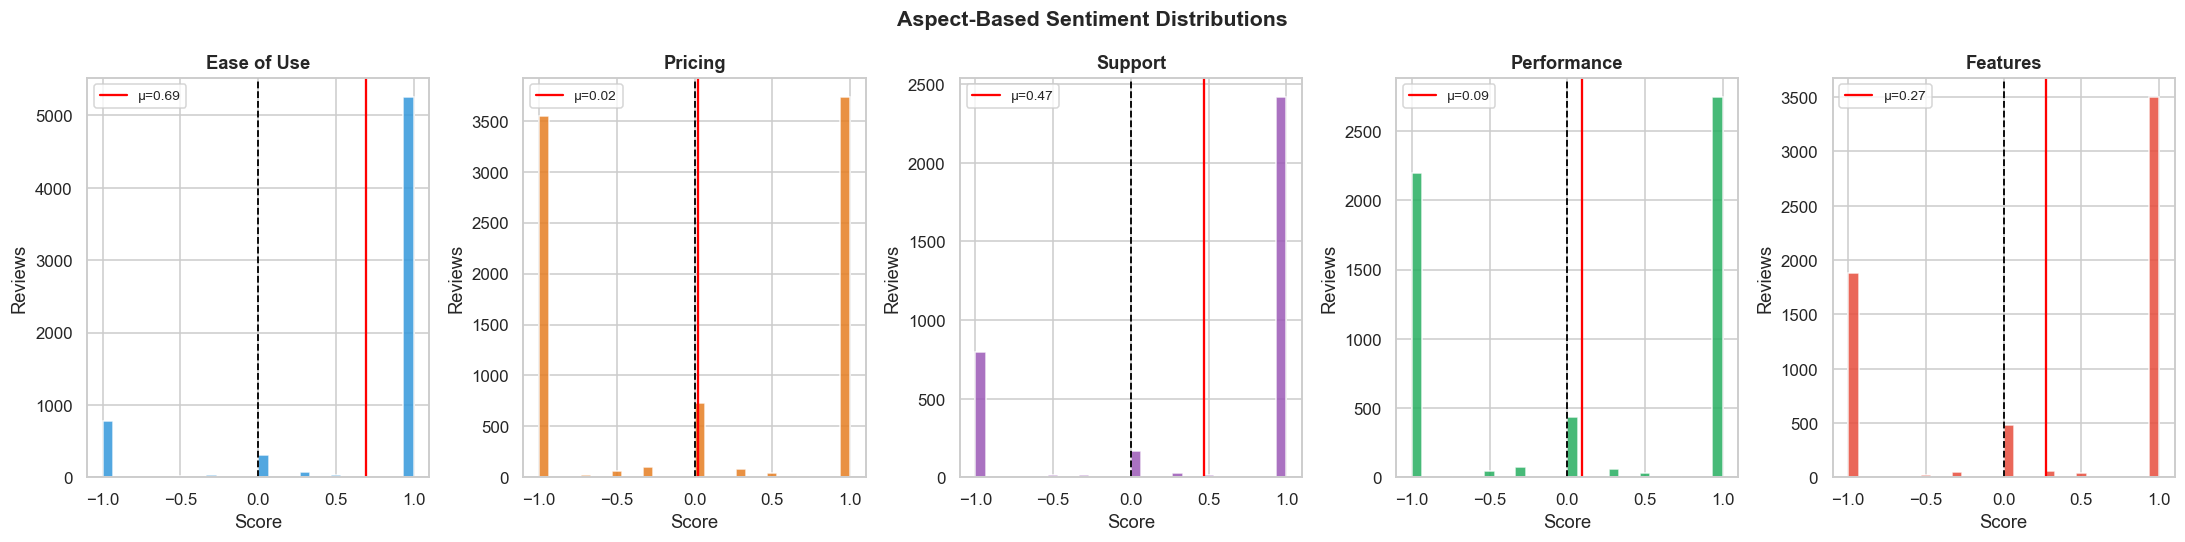

In [22]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
aspect_colors = {
    'absa_ease_of_use': '#3498db', 'absa_pricing': '#e67e22',
    'absa_customer_support': '#9b59b6', 'absa_performance': '#27ae60',
    'absa_features': '#e74c3c'
}
aspect_labels = {
    'absa_ease_of_use': 'Ease of Use', 'absa_pricing': 'Pricing',
    'absa_customer_support': 'Support', 'absa_performance': 'Performance',
    'absa_features': 'Features'
}
for ax, (col, color) in zip(axes, aspect_colors.items()):
    data = reviews[col].dropna()
    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.2)
    ax.axvline(data.mean(), color='red', linestyle='-', linewidth=1.5,
               label=f"μ={data.mean():.2f}")
    ax.set_title(aspect_labels[col], fontweight='bold')
    ax.set_xlabel("Score"); ax.set_ylabel("Reviews")
    ax.legend(fontsize=9)

plt.suptitle("Aspect-Based Sentiment Distributions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('absa_distributions.png', bbox_inches='tight', dpi=130)
plt.show()


## 📦 Step 13: Aggregate to App Level

The recommender needs **one row per app**, not one per review. We aggregate:
- Mean and median sentiment score
- % positive/negative/neutral reviews
- Sentiment consistency (standard deviation)
- Per-aspect mean ABSA scores
- **Hidden Gem flag** — high sentiment but low review count (undiscovered tools)


In [23]:
# Overall sentiment per app
app_sentiment = reviews.groupby('app_id').agg(
    review_count         = ('review_id', 'count'),
    mean_sentiment_score = ('sentiment_score', 'mean'),
    median_sentiment     = ('sentiment_score', 'median'),
    std_sentiment        = ('sentiment_score', 'std'),
    pct_positive         = ('pred_label', lambda x: (x == 2).mean() * 100),
    pct_negative         = ('pred_label', lambda x: (x == 0).mean() * 100),
    pct_neutral          = ('pred_label', lambda x: (x == 1).mean() * 100),
).reset_index()

# ABSA mean per app
absa_cols = [c for c in reviews.columns if c.startswith('absa_')]
for col in absa_cols:
    agg = reviews.groupby('app_id')[col].mean().reset_index()
    agg.columns = ['app_id', col + '_mean']
    app_sentiment = app_sentiment.merge(agg, on='app_id', how='left')

print(f"✅ App-level sentiment aggregated for {len(app_sentiment)} apps")
print("Columns:", list(app_sentiment.columns))


✅ App-level sentiment aggregated for 482 apps
Columns: ['app_id', 'review_count', 'mean_sentiment_score', 'median_sentiment', 'std_sentiment', 'pct_positive', 'pct_negative', 'pct_neutral', 'absa_ease_of_use_mean', 'absa_pricing_mean', 'absa_customer_support_mean', 'absa_performance_mean', 'absa_features_mean']


In [24]:
# Merge with metadata
app_sentiment_full = metadata.merge(app_sentiment, on='app_id', how='left')
print(f"✅ Merged with metadata: {app_sentiment_full.shape}")

# Fill missing values (cold-start apps)
fill_cols = ['mean_sentiment_score','median_sentiment','std_sentiment',
             'pct_positive','pct_negative','pct_neutral','review_count']
for col in fill_cols:
    if col in app_sentiment_full.columns:
        app_sentiment_full[col] = app_sentiment_full[col].fillna(
            app_sentiment_full[col].median()
        )

cold_start = app_sentiment_full['review_count'].isna().sum()
print(f"   Apps with reviews    : {len(app_sentiment_full) - cold_start}")
print(f"   Cold-start apps      : {cold_start} (filled with median values)")


✅ Merged with metadata: (482, 38)
   Apps with reviews    : 482
   Cold-start apps      : 0 (filled with median values)


In [25]:
# Hidden Gem Detection
sent_75 = app_sentiment_full['mean_sentiment_score'].quantile(0.75)
rev_25  = app_sentiment_full['total_reviews'].quantile(0.25)

app_sentiment_full['is_hidden_gem'] = (
    (app_sentiment_full['mean_sentiment_score'] >= sent_75) &
    (app_sentiment_full['total_reviews'] <= rev_25)
).astype(int)

gem_count = app_sentiment_full['is_hidden_gem'].sum()
print(f"💎 Hidden Gems identified: {gem_count} apps")
print(f"   (High sentiment score ≥ {sent_75:.3f} AND review count ≤ {rev_25:.0f})")
print()
gems = (app_sentiment_full[app_sentiment_full['is_hidden_gem'] == 1]
        [['app_name','project_category','mean_sentiment_score','total_reviews','avg_rating']]
        .sort_values('mean_sentiment_score', ascending=False).head(10))
print(gems.to_string(index=False))


💎 Hidden Gems identified: 54 apps
   (High sentiment score ≥ 0.395 AND review count ≤ 20)

                      app_name           project_category  mean_sentiment_score  total_reviews  avg_rating
   PDF AI: Document Summarizer            Productivity AI              0.875410              1    4.600000
      AI Python Code Generator       AI Coding Assistants              0.855305              7    4.214286
             AI Code Generator       AI Coding Assistants              0.849445              7    4.846154
        AI HTML Code Generator       AI Coding Assistants              0.800725              3    4.636363
      AI Description Generator               Marketing AI              0.783998              7    4.909091
Product Plus: AI Product Photo               Marketing AI              0.771281              1    5.000000
AI Chat Assistant - Mosaic 5.0       AI Coding Assistants              0.761243              4    4.285714
    Email Writer: AI Generator Generative Text / Chat

## 📊 Step 14: Final Sentiment Visualisations (for Report)

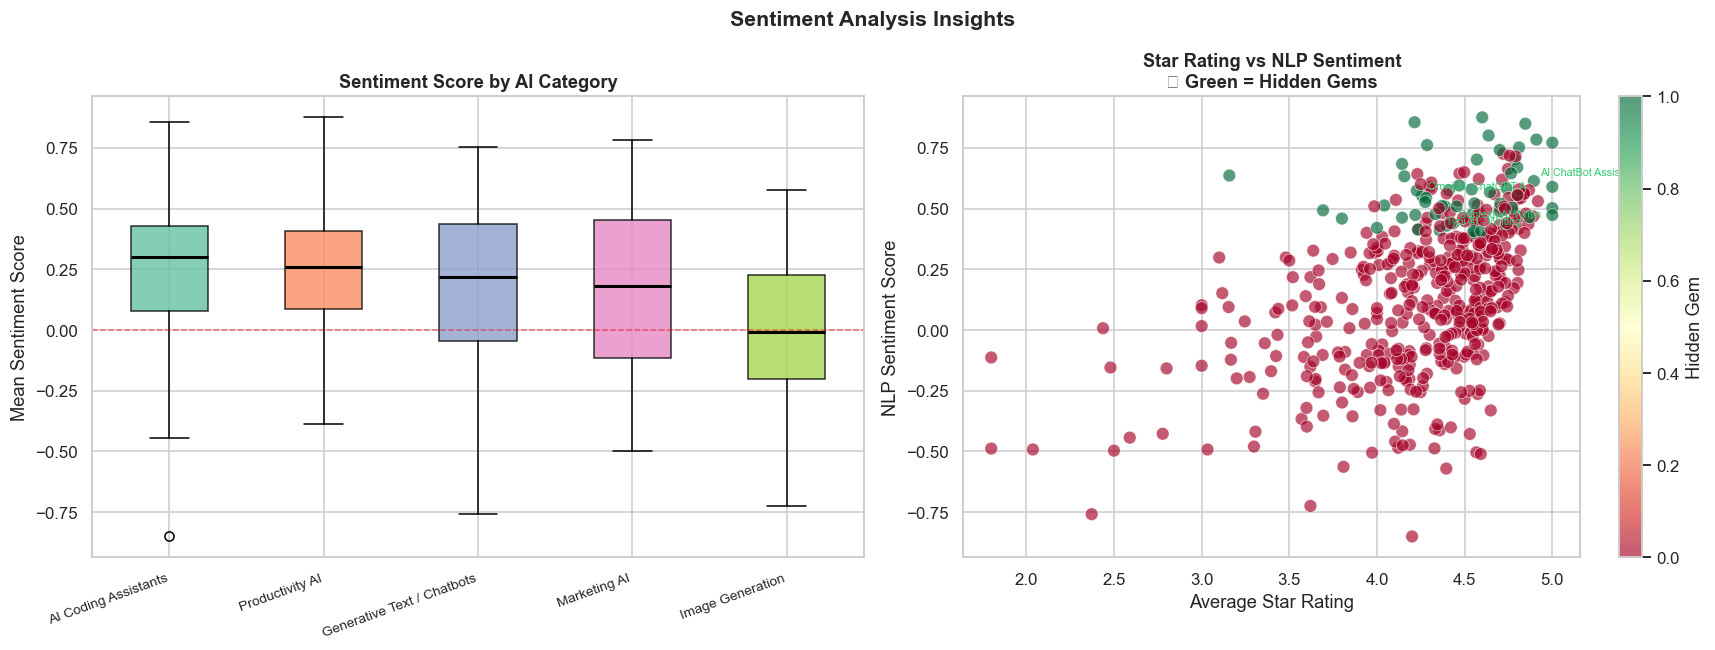

In [26]:
# Chart 1: Sentiment by Category + Scatter vs Star Rating
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_order = (app_sentiment_full.groupby('project_category')['mean_sentiment_score']
             .mean().sort_values(ascending=False).index.tolist())
data_box = [
    app_sentiment_full[app_sentiment_full['project_category'] == cat]['mean_sentiment_score'].dropna().values
    for cat in cat_order
]
bp = axes[0].boxplot(data_box, labels=cat_order, patch_artist=True,
                      medianprops={'color':'black','linewidth':2})
palette = sns.color_palette("Set2", len(cat_order))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color); patch.set_alpha(0.8)
axes[0].set_xticklabels(cat_order, rotation=20, ha='right', fontsize=9)
axes[0].set_title("Sentiment Score by AI Category", fontweight='bold')
axes[0].set_ylabel("Mean Sentiment Score")
axes[0].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)

sc = axes[1].scatter(
    app_sentiment_full['avg_rating'], app_sentiment_full['mean_sentiment_score'],
    c=app_sentiment_full['is_hidden_gem'], cmap='RdYlGn',
    alpha=0.65, s=70, edgecolors='white', linewidth=0.5
)
axes[1].set_xlabel("Average Star Rating"); axes[1].set_ylabel("NLP Sentiment Score")
axes[1].set_title("Star Rating vs NLP Sentiment\n💎 Green = Hidden Gems", fontweight='bold')
for _, row in app_sentiment_full[app_sentiment_full['is_hidden_gem']==1].head(4).iterrows():
    axes[1].annotate(row['app_name'][:18], (row['avg_rating'], row['mean_sentiment_score']),
                     fontsize=7, xytext=(4,4), textcoords='offset points', color='#2ecc71')
plt.colorbar(sc, ax=axes[1], label='Hidden Gem')

plt.suptitle("Sentiment Analysis Insights", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_by_category.png', bbox_inches='tight', dpi=130)
plt.show()


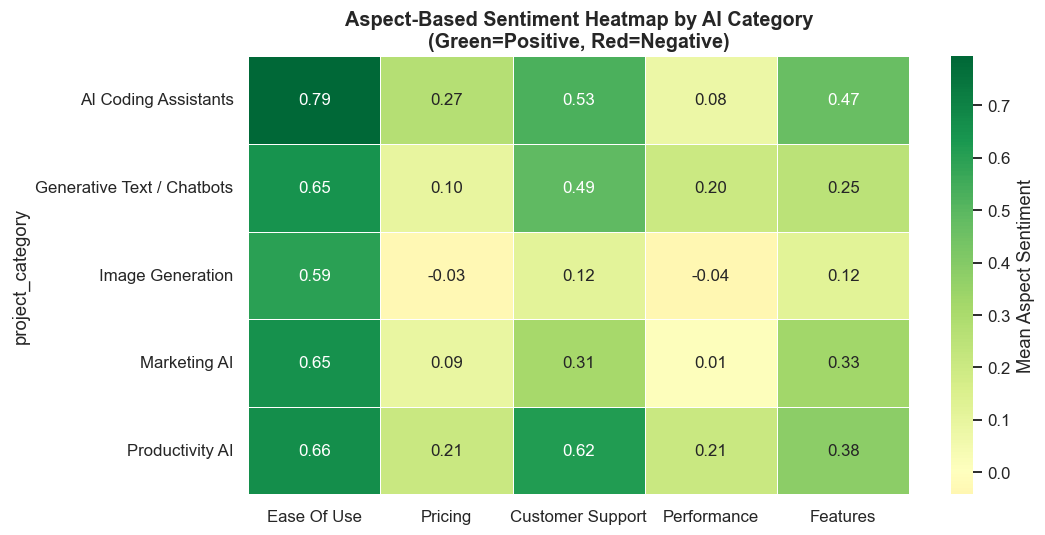

✅ Chart saved: absa_heatmap.png


In [27]:
# Chart 2: ABSA Heatmap by Category
absa_mean_cols = [c for c in app_sentiment_full.columns if c.startswith('absa_') and c.endswith('_mean')]
readable = {c: c.replace('absa_','').replace('_mean','').replace('_',' ').title() for c in absa_mean_cols}
cat_absa = app_sentiment_full.groupby('project_category')[absa_mean_cols].mean()
cat_absa.columns = [readable[c] for c in absa_mean_cols]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(cat_absa, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Mean Aspect Sentiment'})
ax.set_title("Aspect-Based Sentiment Heatmap by AI Category\n(Green=Positive, Red=Negative)",
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('absa_heatmap.png', bbox_inches='tight', dpi=130)
plt.show()
print("✅ Chart saved: absa_heatmap.png")


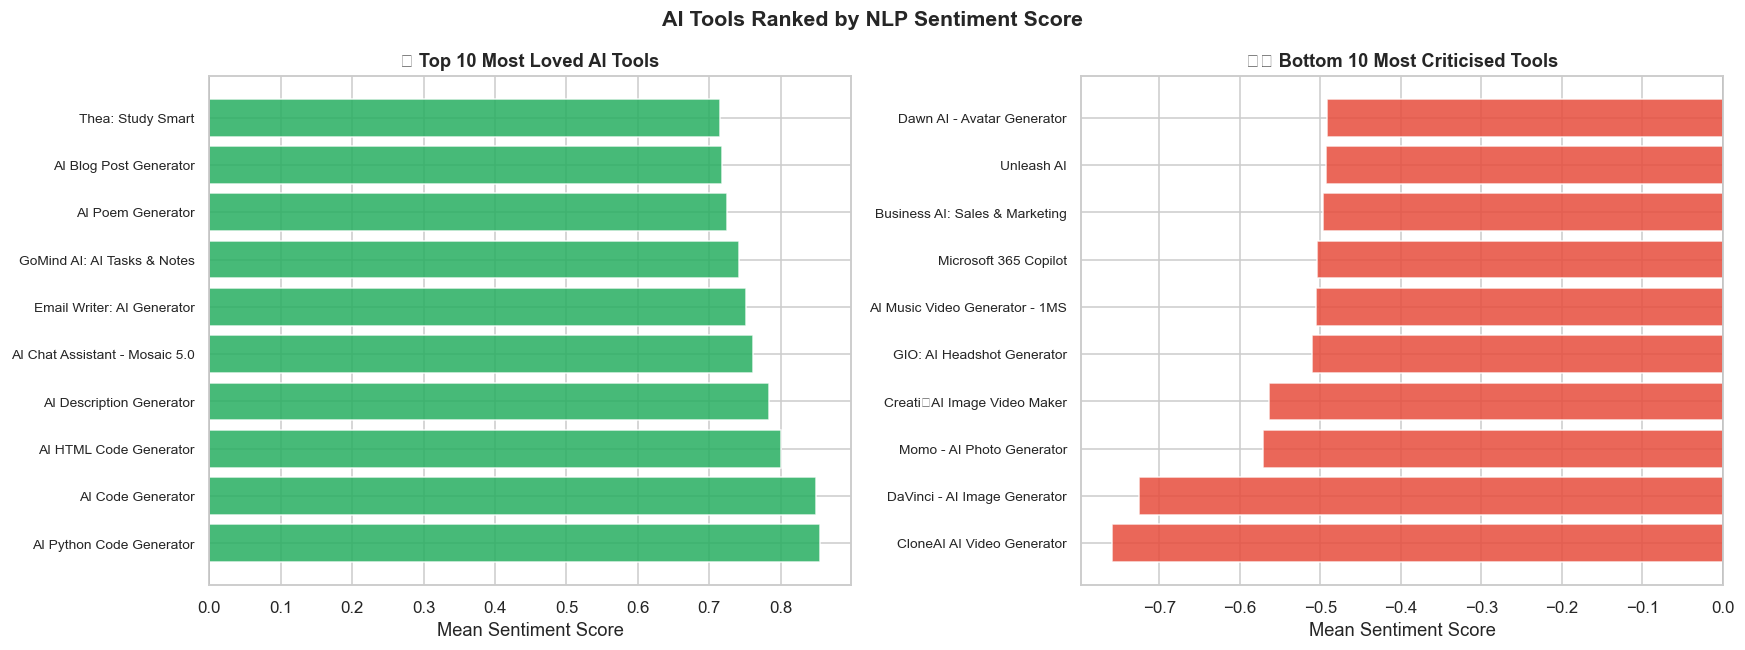

In [28]:
# Chart 3: Top & Bottom 10 Apps by Sentiment Score
qualified = app_sentiment_full[app_sentiment_full['review_count'] >= 10].copy()
top10    = qualified.nlargest(10,  'mean_sentiment_score')
bottom10 = qualified.nsmallest(10, 'mean_sentiment_score')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, df, title, color in [
    (axes[0], top10,    "🏆 Top 10 Most Loved AI Tools",     '#27ae60'),
    (axes[1], bottom10, "⚠️ Bottom 10 Most Criticised Tools", '#e74c3c')
]:
    ax.barh(range(len(df)), df['mean_sentiment_score'].values,
            color=color, edgecolor='white', alpha=0.85)
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels([n[:30] for n in df['app_name'].values], fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel("Mean Sentiment Score")
    ax.axvline(0, color='black', linewidth=1)

plt.suptitle("AI Tools Ranked by NLP Sentiment Score", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top_bottom_apps.png', bbox_inches='tight', dpi=130)
plt.show()


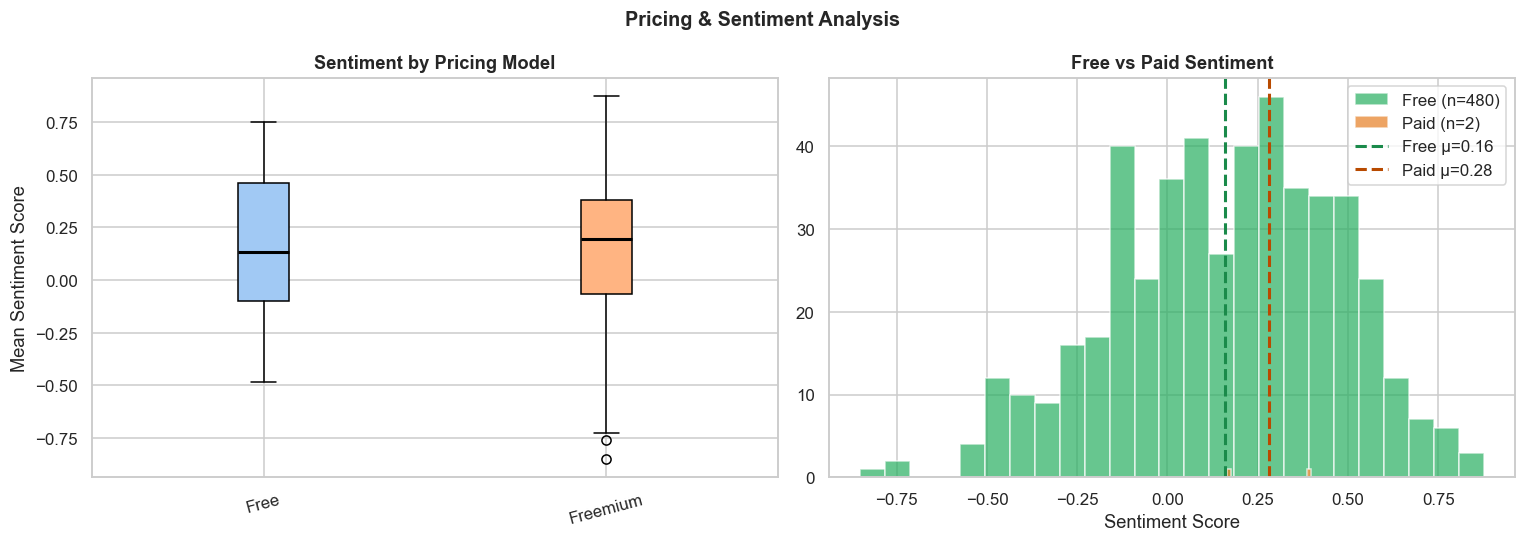

In [29]:
# Chart 4: Free vs Paid Sentiment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pricing_models = app_sentiment_full['pricing_model'].dropna().unique()
data_p, labels_p = [], []
for pm in sorted(pricing_models):
    vals = app_sentiment_full[app_sentiment_full['pricing_model']==pm]['mean_sentiment_score'].dropna()
    if len(vals) > 2:
        data_p.append(vals.values); labels_p.append(pm)

bp3 = axes[0].boxplot(data_p, labels=labels_p, patch_artist=True,
                       medianprops={'color':'black','linewidth':2})
for patch, color in zip(bp3['boxes'], sns.color_palette("pastel", len(labels_p))):
    patch.set_facecolor(color)
axes[0].set_title("Sentiment by Pricing Model", fontweight='bold')
axes[0].set_ylabel("Mean Sentiment Score")
axes[0].tick_params(axis='x', rotation=15)

free_sent = app_sentiment_full[app_sentiment_full['free']==True]['mean_sentiment_score'].dropna()
paid_sent = app_sentiment_full[app_sentiment_full['free']==False]['mean_sentiment_score'].dropna()
axes[1].hist(free_sent, bins=25, alpha=0.7, label=f'Free (n={len(free_sent)})', color='#27ae60', edgecolor='white')
axes[1].hist(paid_sent, bins=25, alpha=0.7, label=f'Paid (n={len(paid_sent)})', color='#e67e22', edgecolor='white')
axes[1].axvline(free_sent.mean(), color='#1a8a4a', linestyle='--', linewidth=2, label=f'Free μ={free_sent.mean():.2f}')
axes[1].axvline(paid_sent.mean(), color='#b84a00', linestyle='--', linewidth=2, label=f'Paid μ={paid_sent.mean():.2f}')
axes[1].set_title("Free vs Paid Sentiment", fontweight='bold')
axes[1].set_xlabel("Sentiment Score"); axes[1].legend()

plt.suptitle("Pricing & Sentiment Analysis", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pricing_sentiment.png', bbox_inches='tight', dpi=130)
plt.show()


## 💾 Step 15: Save All Outputs

Three files are saved for the next notebook (Collaborative Filtering + Hybrid Recommender):

| File | Contents |
|------|----------|
| `review_sentiments.csv` | All reviews with sentiment scores + ABSA columns |
| `app_sentiment_scores.csv` | One row per app — aggregated scores for recommender |
| `nlp_model_metadata.json` | Model performance metrics for report documentation |


In [30]:
# 1. Review-level scores
review_out_cols = [
    'app_id','review_id','user_name','star_rating','review_text','clean_text',
    'review_length','sentiment_label','sentiment_name','pred_label','pred_name',
    'prob_negative','prob_neutral','prob_positive','sentiment_score',
    'review_date','thumbs_up_count','has_reply'
] + [c for c in reviews.columns if c.startswith('absa_')]

reviews[review_out_cols].to_csv('review_sentiments.csv', index=False)
print(f"✅ Saved: review_sentiments.csv  ({len(reviews):,} rows)")

# 2. App-level scores
app_sentiment_full.to_csv('app_sentiment_scores.csv', index=False)
print(f"✅ Saved: app_sentiment_scores.csv ({len(app_sentiment_full):,} rows)")

# 3. Model metadata
model_meta = {
    "model_type": "Logistic Regression",
    "feature_extraction": "TF-IDF (unigrams + bigrams)",
    "tfidf_max_features": 15000,
    "ngram_range": [1, 2],
    "training_samples": int(X_train.shape[0]),
    "test_samples": int(X_test.shape[0]),
    "test_accuracy": round(float(accuracy_score(y_test, y_pred)), 4),
    "test_f1_weighted": round(float(f1_score(y_test, y_pred, average='weighted')), 4),
    "classes": ["Negative", "Neutral", "Positive"],
    "class_weight": "balanced",
    "total_reviews_scored": int(len(reviews)),
    "total_apps_scored": int(len(app_sentiment_full)),
    "hidden_gems_found": int(app_sentiment_full['is_hidden_gem'].sum()),
    "aspects_analysed": list(ASPECT_KEYWORDS.keys()),
    "output_files": ["review_sentiments.csv", "app_sentiment_scores.csv"]
}
with open('nlp_model_metadata.json', 'w') as f:
    json.dump(model_meta, f, indent=2)
print("✅ Saved: nlp_model_metadata.json")

print()
print("=" * 55)
print("📋 FINAL MODEL SUMMARY")
print("=" * 55)
for k, v in model_meta.items():
    print(f"   {k:30s}: {v}")


✅ Saved: review_sentiments.csv  (62,624 rows)
✅ Saved: app_sentiment_scores.csv (482 rows)
✅ Saved: nlp_model_metadata.json

📋 FINAL MODEL SUMMARY
   model_type                    : Logistic Regression
   feature_extraction            : TF-IDF (unigrams + bigrams)
   tfidf_max_features            : 15000
   ngram_range                   : [1, 2]
   training_samples              : 50099
   test_samples                  : 12525
   test_accuracy                 : 0.8003
   test_f1_weighted              : 0.8195
   classes                       : ['Negative', 'Neutral', 'Positive']
   class_weight                  : balanced
   total_reviews_scored          : 62624
   total_apps_scored             : 482
   hidden_gems_found             : 54
   aspects_analysed              : ['ease_of_use', 'pricing', 'customer_support', 'performance', 'features']
   output_files                  : ['review_sentiments.csv', 'app_sentiment_scores.csv']


## ✅ Step 16: Summary & What's Next

---

### What This Notebook Produced

| Step | Task | Output |
|------|------|--------|
| 1–2 | Loaded + explored 69,726 reviews | `eda_overview.png` |
| 3–4 | Text cleaning + preprocessing | `clean_text` column |
| 5 | Distant supervision labelling | `sentiment_label` column |
| 6–7 | TF-IDF extraction + train/test split | TF-IDF matrix (55k × 15k) |
| 8–10 | Trained + evaluated Logistic Regression | `model_evaluation.png` |
| 11 | Sentiment scores for all 69k reviews | `sentiment_score` (−1 to +1) |
| 12 | Aspect-Based Sentiment Analysis | 5 `absa_*` columns |
| 13 | App-level aggregation + hidden gems | `is_hidden_gem` flag |
| 14 | 7 publication-ready visualisations | `*.png` files |
| 15 | Saved all outputs | 2 CSVs + 1 JSON |

---

### Saved Files
```
review_sentiments.csv          ← Review-level scores
app_sentiment_scores.csv       ← App-level scores (main recommender input)
nlp_model_metadata.json        ← For project report
eda_overview.png               ← EDA
sentiment_label_dist.png       ← Class balance
model_evaluation.png           ← Confusion matrix + F1
feature_importance.png         ← Interpretability
validation_score_vs_stars.png  ← Model validation
absa_distributions.png         ← ABSA distributions
absa_heatmap.png               ← ABSA by category
top_bottom_apps.png            ← Ranked apps
pricing_sentiment.png          ← Pricing analysis
sentiment_by_category.png      ← Category analysis
```

---

### 🚀 Next: Notebook 03 — Collaborative Filtering + Hybrid Recommender

In Notebook 03, we will:
1. Build a **User-Item Matrix** from star ratings
2. Apply **Matrix Factorisation (SVD)** for collaborative filtering
3. **Fuse** CF scores with NLP sentiment using the hybrid formula:

```
Hybrid Score = α × CF_Score + β × Sentiment_Score + γ × ABSA_Bonus
              (e.g., 0.50)        (e.g., 0.35)          (e.g., 0.15)
```

4. Build the final **ranking + recommendation function** for the Streamlit app
